코스모화학의 데이터를 받는 중...
코스모화학의 데이터 수집 완료!
코스모화학의 분석 결과
단순 보유 MDD: -64.47%
전략 보유 MDD: -56.11%


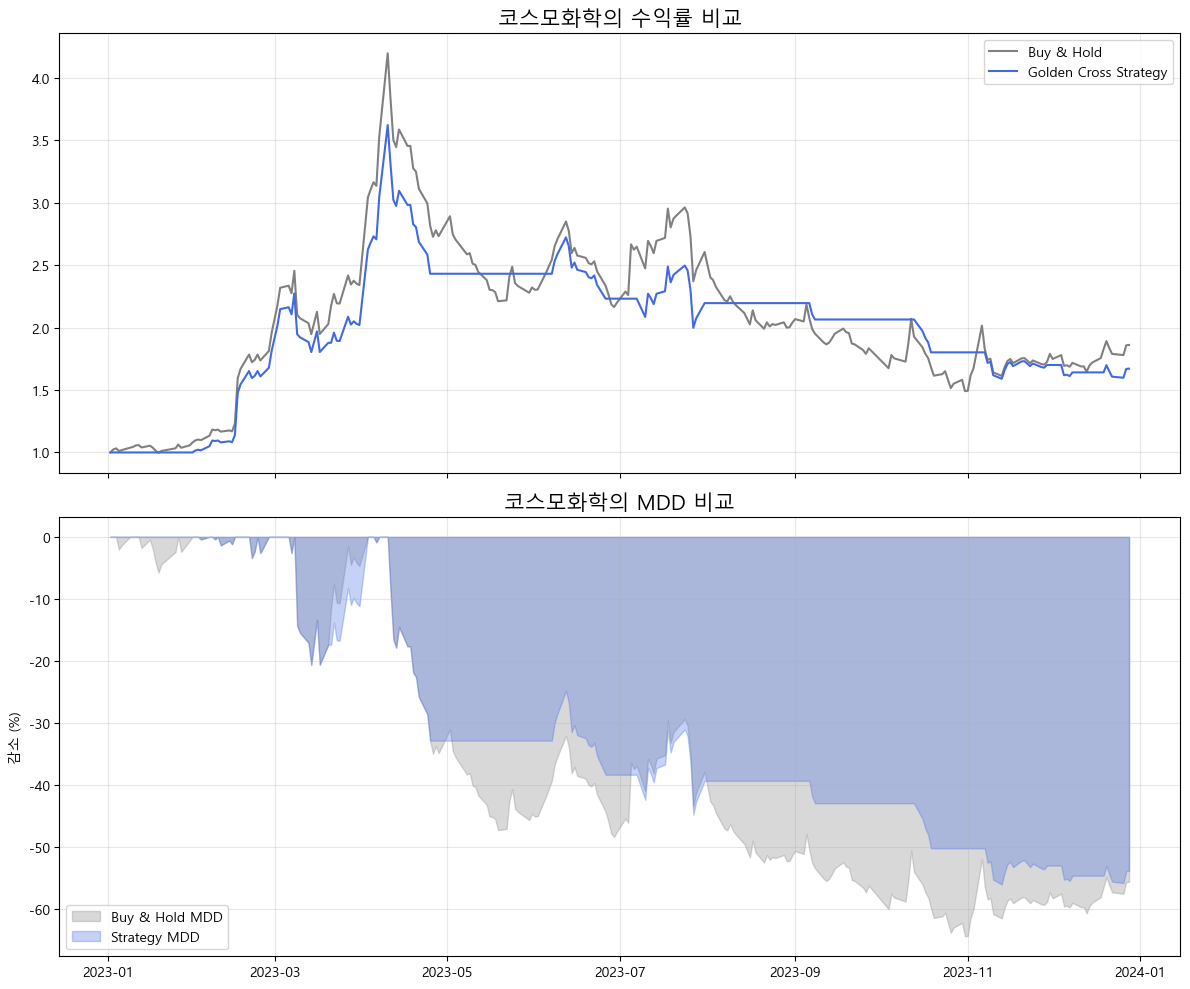


엑셀파일 저장위치: C:\Users\L\Desktop\quant_study\Quant-Python-Study\코스모화학_전략과시장수익률및MDD비교.xlsx


In [14]:
import FinanceDataReader as fdr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#그래프 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

class QuantAnalyzer:
    def __init__(self, code, name):
        self.code = code
        self.name = name
        self.df = None
    
    def fetch_data(self, start_date, end_date):
        print(f"{self.name}의 데이터를 받는 중...")
        self.df = fdr.DataReader(self.code, start_date, end_date)
        print(f"{self.name}의 데이터 수집 완료!")

    def run_backtest(self, short_ma, long_ma): #단기와 장기 이평선 입력해서 결정 가능
        if self.df is None: return #데이터 수집이 안되어있는 경우 함수를 실행하지않고 빠져나온다.
        
        self.df['Short_MA'] = self.df['Close'].rolling(window=short_ma).mean() #단기이평선
        self.df['Long_MA'] = self.df['Close'].rolling(window=long_ma).mean() #장기이평선
        self.df['Signal'] = np.where(self.df['Short_MA']>self.df['Long_MA'], 1, 0) #단기이평선이 장기이평선보다 크면 1

        #수익률 계산
        self.df['Daily_Return'] = self.df['Close'].pct_change() #일간 수익률
        self.df['Strategy_Return'] = self.df['Daily_Return']*self.df['Signal'].shift(1) #전략 실행시 수익률
        self.df['Cum_Daily_Return'] = (1 + self.df['Daily_Return'].fillna(0)).cumprod() #시장의 누적 수익률
        self.df['Cum_Strategy_Return'] = (1 + self.df['Strategy_Return'].fillna(0)).cumprod() #골든크로스 누적 수익률

        #MDD 계산
        self.df['Buy_Hold_Peak'] = self.df['Cum_Daily_Return'].cummax() #buy & hold 시 전고점
        self.df['Buy_Hold_DD'] = (self.df['Cum_Daily_Return'] / self.df['Buy_Hold_Peak']) - 1 #buy & hold 시 하락폭
        self.df['Strategy_Peak'] = self.df['Cum_Strategy_Return'].cummax() #골든크로스 전략 시 전고점
        self.df['Strategy_DD'] = (self.df['Cum_Strategy_Return'] / self.df['Strategy_Peak']) - 1 #골든크로스 전략시 하락폭

        #결과 요약
        result_summary = {
            "final_market_return": (self.df['Cum_Daily_Return'].iloc[-1] - 1)*100, #최종 시장 수익률
            "final_strategy_return": (self.df['Cum_Strategy_Return'].iloc[-1] - 1)*100, #최종 전략 수익률
            "buy_hold_MDD": self.df['Buy_Hold_DD'].min()*100, #buy & hold 시 최대 하락폭
            "strategy_MDD": self.df['Strategy_DD'].min()*100 # 전략 실행시 최대 하락폭
        }

        return result_summary

    def visualize_result(self):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

        #상단 그래프, 수익률 비교
        ax1.plot(self.df.index, self.df['Cum_Daily_Return'], label='Buy & Hold', color='gray')
        ax1.plot(self.df.index, self.df['Cum_Strategy_Return'], label='Golden Cross Strategy', color='royalblue')
        ax1.set_title(f"{self.name}의 수익률 비교", fontsize=15)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        #하단 그래프, MDD 비교
        ax2.fill_between(self.df.index, self.df['Buy_Hold_DD']*100, 0, label='Buy & Hold MDD',color='gray', alpha=0.3)
        ax2.fill_between(self.df.index, self.df['Strategy_DD']*100, 0, label='Strategy MDD',color='royalblue', alpha=0.3)
        ax2.set_title(f"{self.name}의 MDD 비교", fontsize=15)
        ax2.set_ylabel("감소 (%)")
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

#---------------------------실행 코드----------------------------
cosmo_chemical = QuantAnalyzer('005420', '코스모화학')
cosmo_chemical.fetch_data('2023-01-01', '2023-12-31')
summary = cosmo_chemical.run_backtest(5, 20)

print(f"{cosmo_chemical.name}의 분석 결과")
print(f"단순 보유 MDD: {summary['buy_hold_MDD']:.2f}%")
print(f"전략 보유 MDD: {summary['strategy_MDD']:.2f}%")

cosmo_chemical.visualize_result()

#엑셀로 저장
file_name = f"{cosmo_chemical.name}_전략과시장수익률및MDD비교.xlsx"
cosmo_chemical.df.to_excel(file_name)
full_path = os.path.abspath(file_name)

print("\n" + "="*40)
print(f"엑셀파일 저장위치: {full_path}")
print("="*40)